<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

####  Análisis y Procesamiento de Señales
# Trabajo Práctico Nº 1
#### Mariano Gonzalez


### Declaro funcion generador de senoidal, calculador energia-potencia y variables globales

In [31]:
import numpy as np
import matplotlib.pyplot as plt

#%%Generador de senoidal
def mi_funcion_sen( vmax, dc, f0, ph, N, fs):
    tt=np.arange(0,N+1,1)*(1/fs)
    xx=dc + vmax*np.sin(2*np.pi*f0*tt + ph)
    return tt,xx 

# %% funcion para calcular energia y potencia
def calcular_energia_potencia(x, fss):
    Ts = 1/fss
    NN = len(x)
    # Energía discreta
    energia = np.sum(np.abs(x)**2) * Ts
    # Potencia promedio
    potencia = np.sum(np.abs(x)**2) / NN
    return energia, potencia

tono=2000 #f0
fase= np.pi/2  #fase
fss= 100000 #frecuencia de muestreo
ts=1/fss
nn=100 #muestra
#nn=fss/tono # para ver un solo ciclo

# Ejercicio 1
#### 1) Señal sinusoidal de 2KHz.
#### 2) Misma señal amplificada 3 dB y desfasada en π/2.
Si la primera señal tenia una amplitud de 1V, cuando la amplifico 3db seria el doble. Entonces la amplificada va a tener 2V de amplitud

Senoide 2kHz -> Energía: 0.0005 Potencia: 0.49504950495049505
Senoide +3db -> Energía: 0.0020400000000000006 Potencia: 2.0198019801980203
si la energia tiende a cero entonces la señal es de potencia


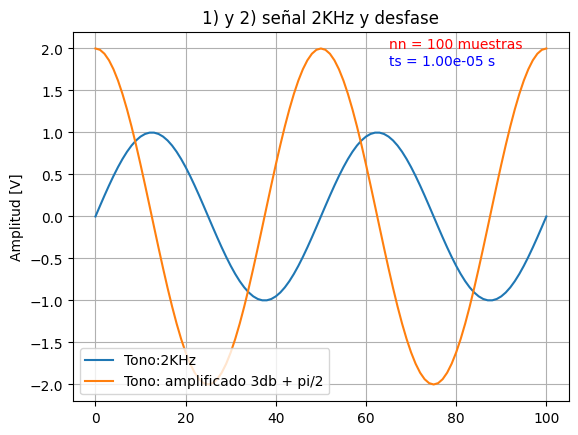

In [39]:
tt, xx = mi_funcion_sen( vmax = 1, dc = 0, f0 = tono, ph=0,N=nn, fs =fss)

tt2, xx2 = mi_funcion_sen( vmax = 2, dc = 0, f0 = tono, ph=fase,N=nn, fs = fss)

E1, P1 = calcular_energia_potencia(xx, fss)
print("Senoide 2kHz -> Energía:", E1, "Potencia:", P1)

E2, P2 = calcular_energia_potencia(xx2, fss)
print("Senoide +3db -> Energía:", E2, "Potencia:", P2)
print("si la energia tiende a cero y la potencia es finita entonces la señal es de potencia")

plt.figure(1)
plt.clf()
plt.grid()
plt.title('1) y 2) señal 2KHz y desfase')
plt.plot(xx, label='Tono:2KHz')
plt.plot(xx2, label='Tono: amplificado 3db + pi/2' )
plt.ylabel('Amplitud [V]')
##plt.xlabel('Tiempo [s]')
plt.text(65, 2, f"nn = {nn} muestras", fontsize=10, color="red")
plt.text(65, 1.8, f"ts = {ts:.2e} s", fontsize=10, color="blue")
plt.legend()
plt.show()





#### 3) Misma señal modulada en amplitud por otra señal sinusoidal de frecuencia de 1000 KHz.
Siendo el tono=2000Hz, tonces la moduladora es de tono/2


Senoide 2kHz -> Energía: 0.001 Potencia: 0.9900990099009901
si la energia tiende a cero y la potencia es finita entonces la señal es de potencia


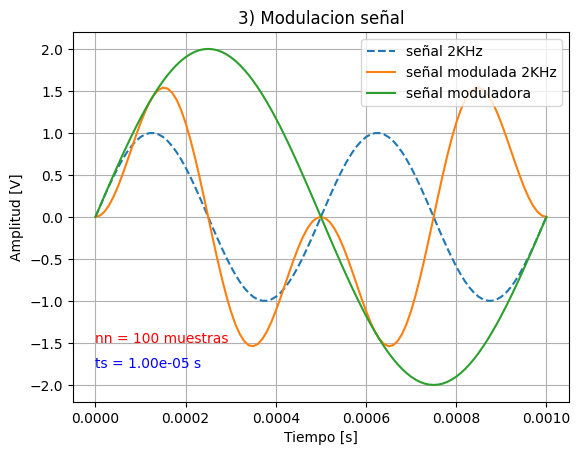

In [40]:
#%%Misma señal (primera) modulada en amplitud por otra señal sinusoidal de la mitad de la frecuencia.
f_mod = tono/2
portadora=xx
tt3, modu = mi_funcion_sen( vmax = 2, dc = 0, f0 = f_mod, ph=0,N=nn, fs = fss)

AM= portadora*modu

E3, P3 = calcular_energia_potencia(AM, fss)
print("Modulada -> Energía:", E3, "Potencia:", P3)
print("si la energia tiende a cero y la potencia es finita entonces la señal es de potencia")


plt.figure(2)
plt.clf()
plt.grid()
plt.plot(tt, xx, '--', label='señal 2KHz')
plt.plot(tt, AM, label='señal modulada 2KHz')
plt.plot(tt3, modu, label='señal moduladora')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')
plt.title('3) Modulacion señal')
plt.text(0.000, -1.5, f"nn = {nn} muestras", fontsize=10, color="red")
plt.text(0.000, -1.8, f"ts = {ts:.2e} s", fontsize=10, color="blue")
plt.legend()
plt.show()




#### 4) Misma señal con efecto de saturación al 75% de su amplitud. Ayuda: ver numpy.clip().
Voy explicando como uso la funcion clip para recortar la señal en los comentarios del codigo

Senoide 2kHz -> Energía: 0.0007474939204218361 Potencia: 0.7400929905166693
si la energia tiende a cero entonces la señal es de potencia


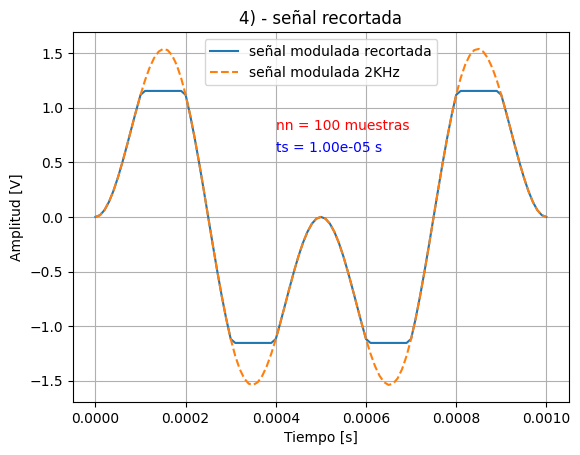

In [38]:
#%% 4) Señal anterior recortada al 75% de su amplitud

limite = 0.75 * np.max(np.abs(AM)) #toma el valor absoluto de cada muestra de 
#la señal modulada (AM del item anterior), es decir que convierte todo a valores positivos
# y ya establezco el limite de 0.75, guardandolo en la variable limite 

recortada = np.clip(AM, -limite, limite) # aca uso la funcion clip que limita los valores del
# array: lo que supera + - limite lo reemplaza con lo calculado antes

E4, P4 = calcular_energia_potencia(recortada, fss)
print("Senoide recordata -> Energía:", E4, "Potencia:", P4)
print("si la energia tiende a cero y la potencia es finita entonces la señal es de potencia")


plt.figure(3)
plt.clf()
plt.grid()
plt.plot(tt, recortada, label='señal modulada recortada')
plt.plot(tt, AM, '--', label='señal modulada 2KHz')
plt.title('4) - señal recortada')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')

plt.text(0.0004, 0.8, f"nn = {nn} muestras", fontsize=10, color="red")
plt.text(0.0004, 0.6, f"ts = {ts:.2e} s", fontsize=10, color="blue")

plt.legend()
plt.show()




#### 5) Una señal cuadrada de 4KHz

Senoide 2kHz -> Energía: 0.001 Potencia: 0.9900990099009901
si la energia tiende a cero entonces la señal es de potencia


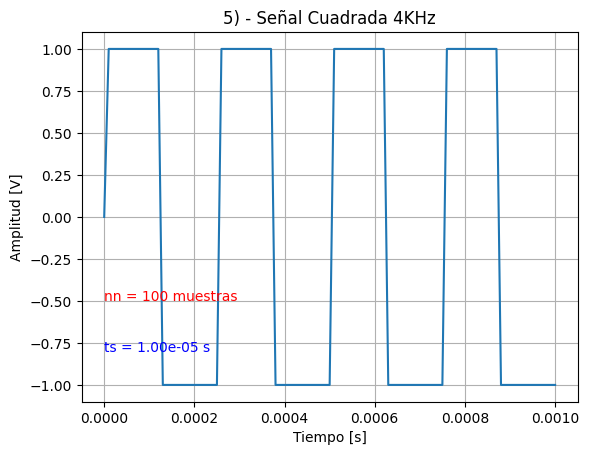

In [41]:
#%% 5) Una señal cuadrada de 4KHz.
tono_cua=4000 #señal de 4KHz
#nn=fss/tono_cua # para ver un solo ciclo
nn=100
tt5, xx5 = mi_funcion_sen( vmax = 2, dc = 0, f0 = tono_cua, ph=0,N=nn, fs = fss)

cuadrada = np.sign(xx5) # np.sign da una cuadrada simétrica entre -1 y +1

E5, P5 = calcular_energia_potencia(cuadrada, fss)
print("Señal cuadrada -> Energía:", E5, "Potencia:", P5)
print("si la energia tiende a cero y la potencia es finita entonces la señal es de potencia")

plt.figure(4)
plt.clf()
plt.grid()
plt.plot(tt5, cuadrada)
plt.title('5) - Señal Cuadrada 4KHz')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')

plt.text(0.000, -0.5, f"nn = {nn} muestras", fontsize=10, color="red")
plt.text(0.000, -0.8, f"ts = {ts:.2e} s", fontsize=10, color="blue")
plt.show()





## 6) Un pulso rectangular de 10ms.
Aqui cambiamos el paradigma de usar una senoidal, armo un vector e impongo el la amplitud en el tiempo requerido
Respecto a la clasificacion del tipo de señal:
Como es una señal no periodica debe ser una señal de energia, con una prueba total de 30ms los valores son: Energía: 0.00999 Potencia: 0.0333.
Pero si extiendo a 1s (modificando la variable tt_total=1) la potencia cae: Energía: 0.00999 Potencia: 0.00999

Pulso 10ms -> Energía: 0.00999 Potencia: 0.333
si la energia tiende a cero entonces la señal es de potencia, leer observacion en el encabezado


Text(0.5, 0, 'Tiempo [s]')

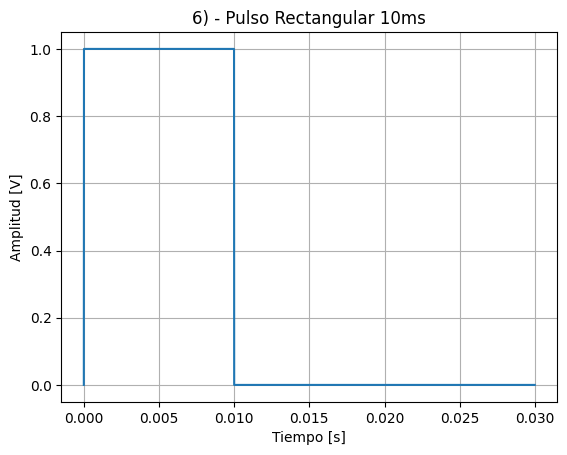

In [43]:
#%% 6) Un pulso rectangular de 10ms
#cambiamos el modo de trabajar, ya no necesito una senoidal

tt_pulso= 0.01 # 10 ms
tt_total=0.03 #duracion del experimento
amplitud=1 # valor alto del pulso, 1V

N= int(fss * tt_total) # vector de tiempo
ttp = np.arange(0, N) * (1/fss) 

pulso = np.zeros(N) # lleno de ceros el vector 
N_pulso = int(fss * tt_pulso) # asigno la duracion
pulso[1:N_pulso] = amplitud # impongo el valor amplitud desde el índice 1 hasta el índice N_pulso-1
# lo hice desde el 1 asi se ve cuando sube, si le quito el 1 arranca en 1 desde 0

#como es una señal no periodica debe ser una señal de energia, con una prueba total de 30ms
#los valores son Energía: 0.00999 Potencia: 0.0333
#pero si extiendo a 1s (tt_total=1) la potencia cae Energía: 0.00999 Potencia: 0.00999
E6, P6 = calcular_energia_potencia(pulso, fss)
print("Pulso 10ms -> Energía:", E6, "Potencia:", P6)
print("si la energia tiende a cero y la potencia es finita entonces la señal es de potencia, leer observacion en el encabezado")

plt.figure(5)
plt.clf()
plt.grid()
plt.plot(ttp, pulso)
plt.title('6) Pulso Rectangular 10ms')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')



# Ejercicio 2


In [5]:
from IPython.display import IFrame

# Mostrar un PDF embebido en la notebook
IFrame("./TS1_ejer2_a-b-c.pdf", width=1000, height=1000)